# <center>**Diabetes Prediction Using Clinical and Lifestyle Data**</center>

### **Introduction**

1. Diabetes is a chronic condition that affects millions of people worldwide. Early identification of individuals at risk can help reduce complications and improve quality of life. This project focuses on predicting diabetes using clinical indicators and lifestyle factors from healthcare data.

2. The dataset contains information such as age, gender, BMI, glucose level, fasting blood sugar, blood pressure, insulin, smoking status, physical activity, diet, sleep patterns, family history, and HbA1c. These variables are medically associated with diabetes risk.

3. This project applies data cleaning, exploratory data analysis, feature engineering, and machine learning modelling techniques to a real healthcare dataset. The work directly aligns with the objectives of the course by applying analytics methods to solve a practical healthcare problem.


## **Exploratory Data Analysis (EDA)**

### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")

### Load and Check Data

In [ ]:
#Load the dataset as 'df'
df = pd.read_csv('diabetes_prediction_dataset.csv')

In [3]:
#Overview of data
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [4]:
df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


*At the first overview of data, we can see that we have no null datas. But still, we need to check if we have such datas as 'no info'.  Gonna get to that later. Although no null values are present, the ‘No Info’ category in smoking_history acts as a placeholder for missing data. This highlights that missing information can exist even when null values are not explicitly recorded.*

In [5]:
#Shape of data
df.shape

(100000, 9)

In [6]:
#First look at the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [7]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


Here we see the description of numerical features. These might give us ideas about our future works.

### *Variable Description:*

&#10148; Gender: Gender refers to the biological sex of the individual, which can have an impact on their susceptibility to diabetes.</br>

&#10148; Age: Age is an important factor as diabetes is more commonly diagnosed in older adults.Age ranges from 0-80 in our dataset.</br>

&#10148; Hypertension: Hypertension is a medical condition in which the blood pressure in the arteries is persistently elevated.</br>

&#10148; Heart Disease: Heart disease is another medical condition that is associated with an increased risk of developing diabetes.</br>

&#10148; Smoking History: Smoking history is also considered as a risk factor on Diabetes. It represents smoking history of the patient.</br>

&#10148; BMI(Body Mass Index): BMI (Body Mass Index) is a measure of body fat based on weight and height. Patients with higher BMI are known for having more risk of suffering from diabetes.</br>

&#10148; HbA1c Level: HbA1c (Hemoglobin A1c) level is a measure of a person's average blood sugar level over the past 2-3 months.</br>

&#10148; Blood Glucose Level: Blood glucose level refers to the amount of glucose in the bloodstream at a given time.</br>

&#10148; Diabetes: Represents the patient if he/she has diabetes or not. 0 is negative, 1 is positive.</br>

Our numerical variables are:

    Age
    BMI
    HbA1c Level
    Blood Glucose Level

Age BMI HbA1c Level Blood Glucose Level

Our categorical variables are:

    Gender
    Hypertension
    Heart Disease
    Smoking History
    Diabetes


### Data Quality

In [8]:
# Checking null values / Missing Values
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [9]:
missing = df.isnull().sum()
percent = (missing/len(df))*100
pd.DataFrame({'Missing Values':missing,'Percent':percent})

,Missing Values,Percent
gender,0,0.0
age,0,0.0
hypertension,0,0.0
heart_disease,0,0.0
smoking_history,0,0.0
bmi,0,0.0
HbA1c_level,0,0.0
blood_glucose_level,0,0.0
diabetes,0,0.0


In [10]:
# Handle duplicates
duplicate_rows_data = df[df.duplicated()]
print("number of duplicate rows: ", duplicate_rows_data.shape)

number of duplicate rows:  (3854, 9)


In [11]:
# Droping the dups & shape of size after droping
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (96146, 9)


In [12]:
# Converting categorical columns

df["gender"] = df["gender"].astype("category")
df["smoking_history"] = df["smoking_history"].astype("category")

In [13]:
categorical_cols = ["gender","smoking_history"]
for col in categorical_cols:
    df[col] = df[col].astype("category")

### Basic Data Analysis

On this analysis, will compare features and try go gather more information about the data

In [14]:
# Gender & Diabetes
df[["gender","diabetes"]].groupby(["gender"], as_index = False).mean().sort_values(by="gender",ascending = False)

,gender,diabetes
2,Other,0.000000
1,Male,0.100958
0,Female,0.079183


Based on the above table, male patients tends to have diabetes more than when its compared to female patients but the difference is really less. This gives, gender has nothing to do with diabetes according to this data

In [15]:
# Hypertension & Diabetes
df[["hypertension","diabetes"]].groupby(["hypertension"], as_index = False).mean().sort_values(by="hypertension",ascending = False)

,hypertension,diabetes
1,1,0.279587
0,0,0.072120


Based on the above table, can see that Hypertension has a low effect on diabetes. It is low but there is an effect on having diabetes by HyperTension

In [16]:
# Heart Disease & Diabetes 
df[["heart_disease","diabetes"]].groupby(["heart_disease"], as_index = False).mean().sort_values(by="heart_disease",ascending = False)

,heart_disease,diabetes
1,1,0.322967
0,0,0.078234


Based on the table, it shows the effect of Heart Disease on Diabetes is almost as same as Hypertension

In [17]:
# Smoking History & Diabetes
df[["smoking_history","diabetes"]].groupby(["smoking_history"], as_index = False).mean().sort_values(by="smoking_history",ascending = False)

,smoking_history,diabetes
5,not current,0.108371
4,never,0.097011
3,former,0.170986
2,ever,0.118059
1,current,0.103077
0,No Info,0.043938


*Smoking history does not show a strong visual separation with diabetes. However, statistical testing later confirms a significant association, indicating that the relationship is not clearly visible through simple aggregation.*

### Shows diabetes distribution

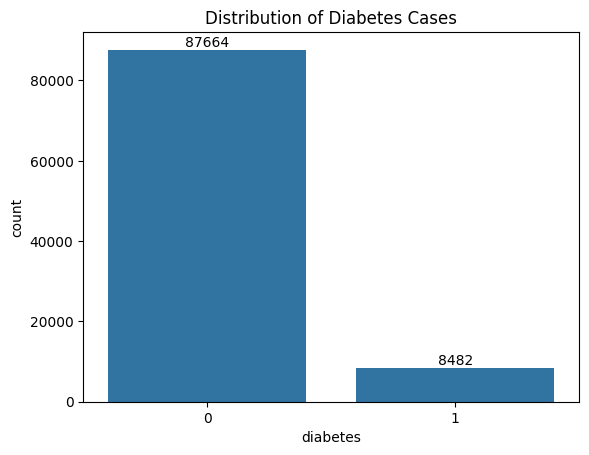

In [18]:
sns.countplot(x="diabetes", data=df)
plt.bar_label(plt.gca().containers[0])
plt.title("Distribution of Diabetes Cases")
plt.show()

*This imbalance can affect model performance, especially for predicting diabetic cases. Therefore, evaluation metrics such as precision, recall, and F1 score are important in addition to accuracy.*

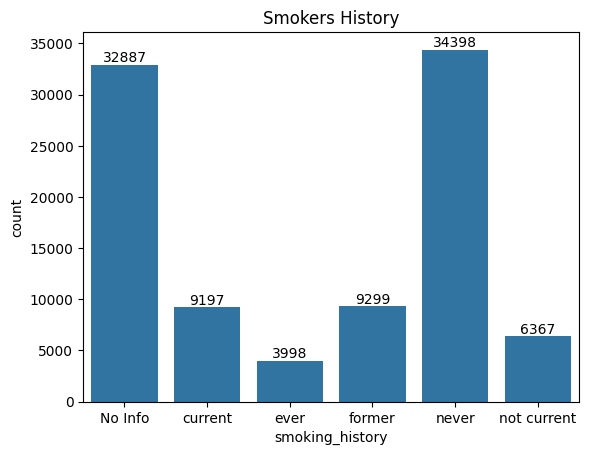

In [19]:
sns.countplot(x="smoking_history",data=df)
plt.bar_label(plt.gca().containers[0])
plt.title("Smokers History")
plt.show()

## **Univariate Analysis**

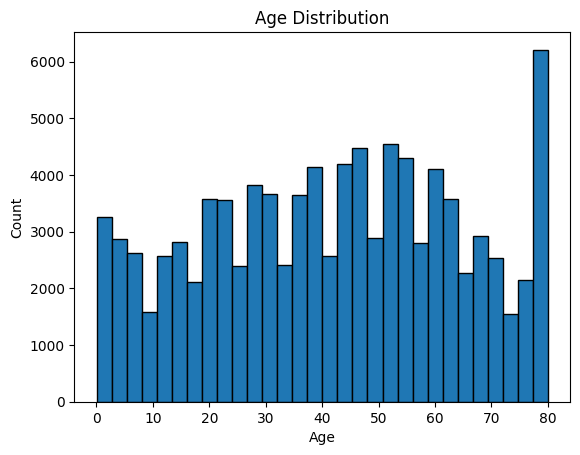

In [20]:
# Histogram for age

plt.hist(df['age'], bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

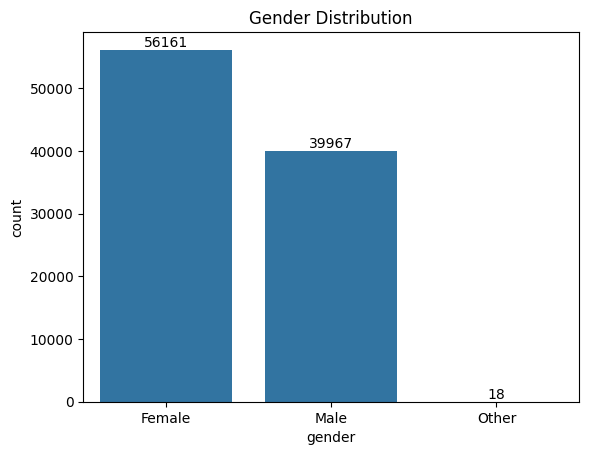

In [21]:
# Bar plot for gender
sns.countplot(x='gender', data=df)
plt.bar_label(plt.gca().containers[0])
plt.title('Gender Distribution')
plt.show()

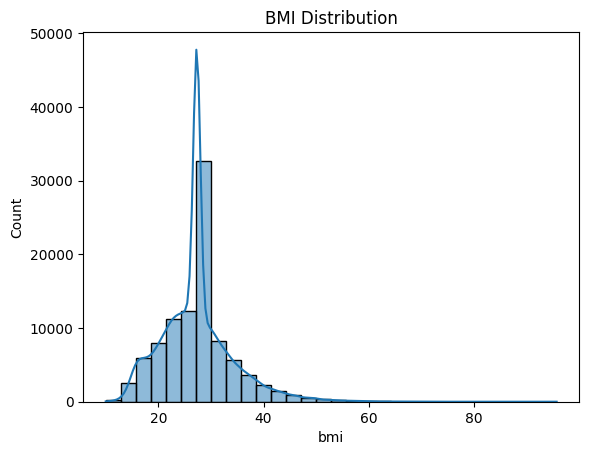

In [22]:
# Distribution plot for BMI
sns.histplot(df['bmi'], kde=True,bins=30)
plt.title('BMI Distribution')
plt.show()

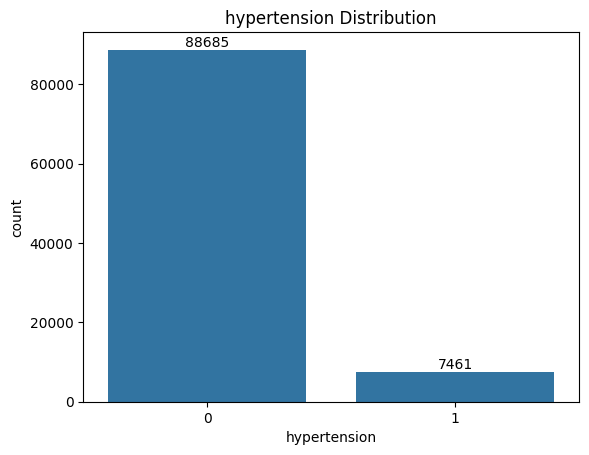

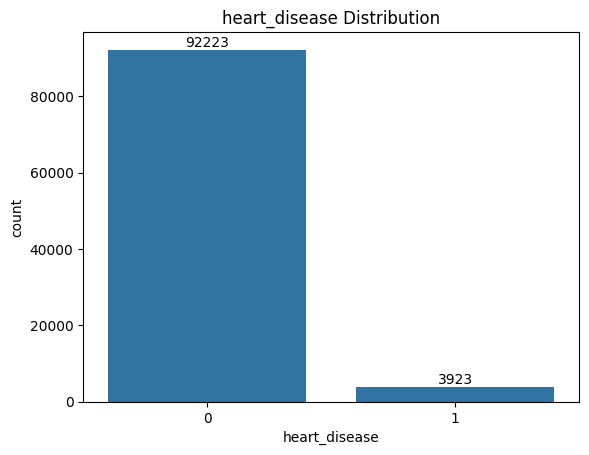

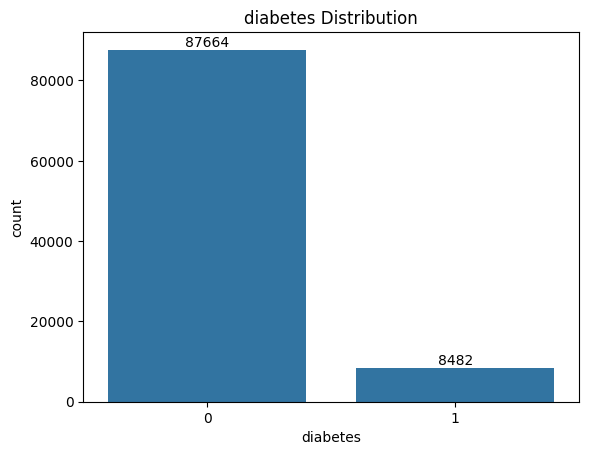

In [23]:
# Count plots for binary variables
for col in ['hypertension', 'heart_disease', 'diabetes']:
    sns.countplot(x=col, data=df)
    plt.bar_label(plt.gca().containers[0])
    plt.title(f'{col} Distribution')
    plt.show()

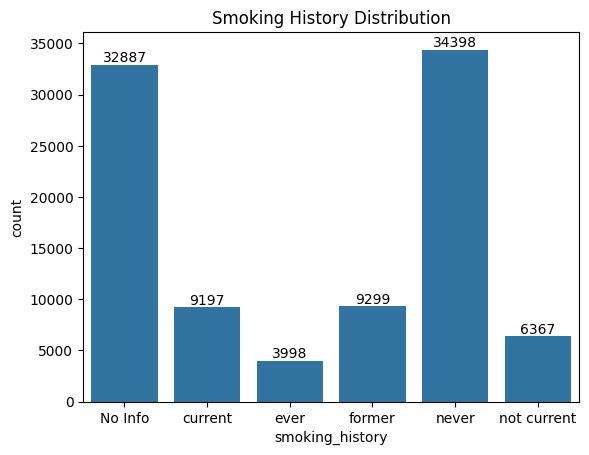

In [24]:
# Count plot for smoking history
sns.countplot(x='smoking_history', data=df)
plt.bar_label(plt.gca().containers[0])
plt.title('Smoking History Distribution')
plt.show()

### Bivariative Analysis

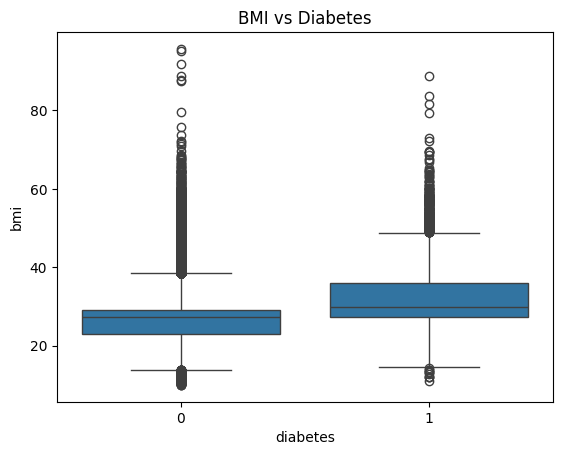

In [25]:
# Boxplot BMI vs Diabetes classification
sns.boxplot(x='diabetes', y='bmi', data=df)
plt.title('BMI vs Diabetes')
plt.show()

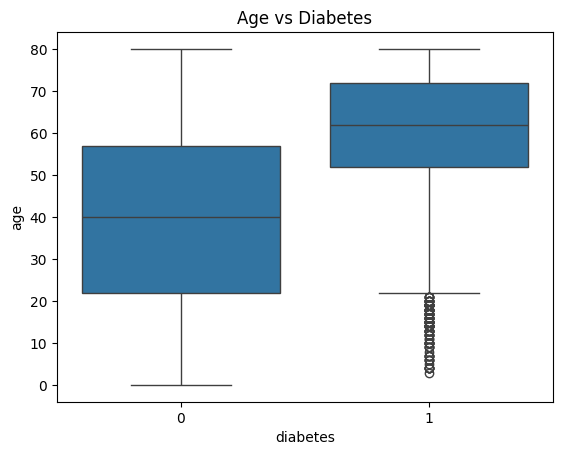

In [26]:
# Boxplot Age vs Diabetes classification
sns.boxplot(x='diabetes', y='age', data=df)
plt.title('Age vs Diabetes')
plt.show()

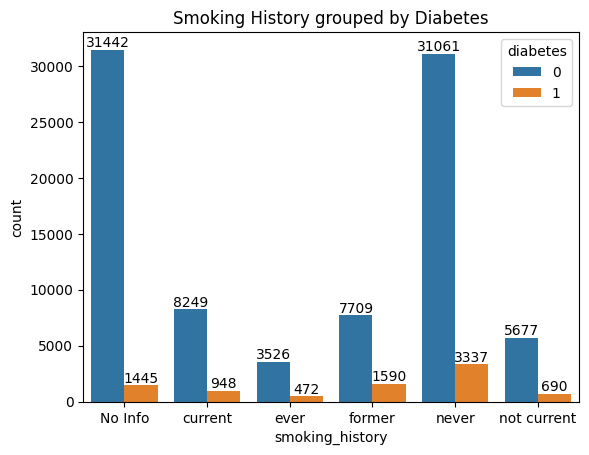

In [27]:
# CountPlot smoking history grouped by diabetes
ax = sns.countplot(x='smoking_history', hue='diabetes', data=df)
plt.title('Smoking History grouped by Diabetes')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

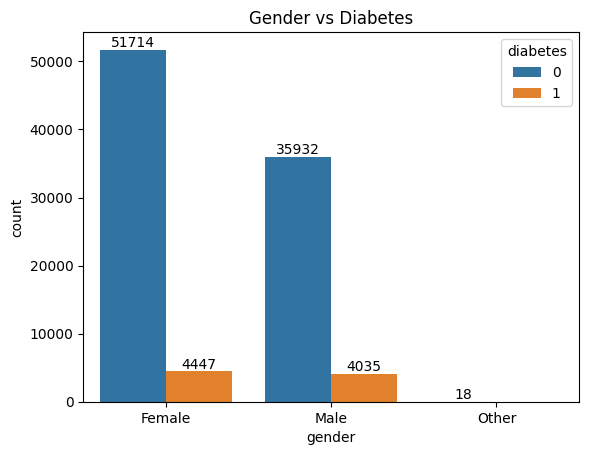

In [28]:
# Count plot of gender vs diabetes
sns.countplot(x='gender', hue='diabetes', data=df)
for container in plt.gca().containers:
    plt.bar_label(container)
plt.title('Gender vs Diabetes')
plt.show()

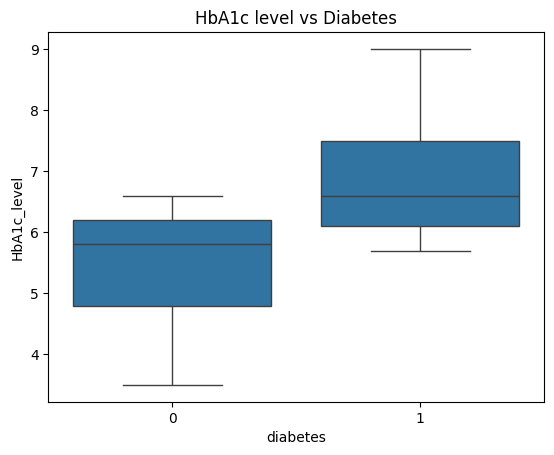

In [29]:
# Boxplot HbA1c level vs Diabetes classification
sns.boxplot(x='diabetes', y='HbA1c_level', data=df)
plt.title('HbA1c level vs Diabetes')
plt.show()

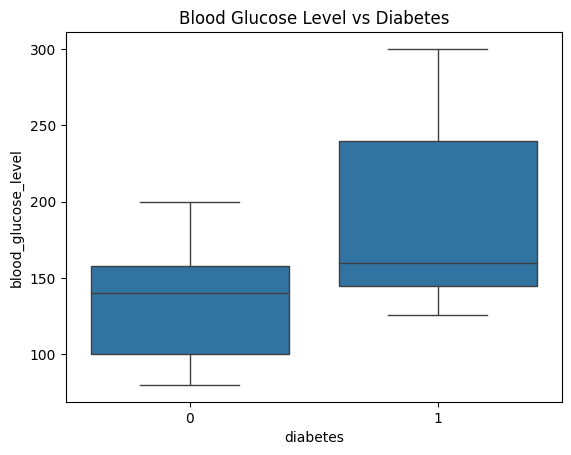

In [30]:
# Boxplot blood glucose level vs Diabetes classification
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df)
plt.title('Blood Glucose Level vs Diabetes')
plt.show()

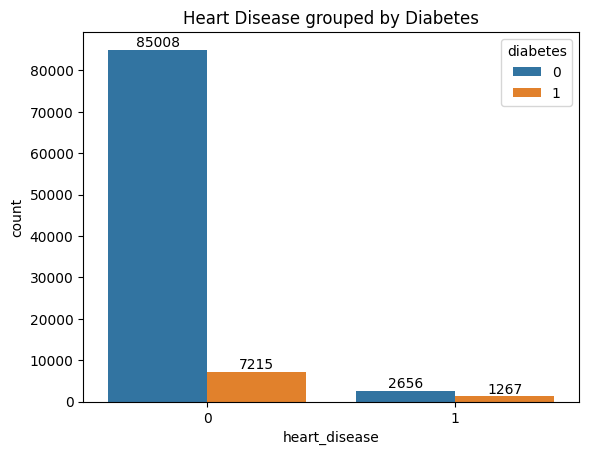

In [31]:
# Plot heart disease grouped by diabetes
ax = sns.countplot(x='heart_disease', hue='diabetes', data=df)
plt.title('Heart Disease grouped by Diabetes')
for container in ax.containers:
    ax.bar_label(container)
plt.show()

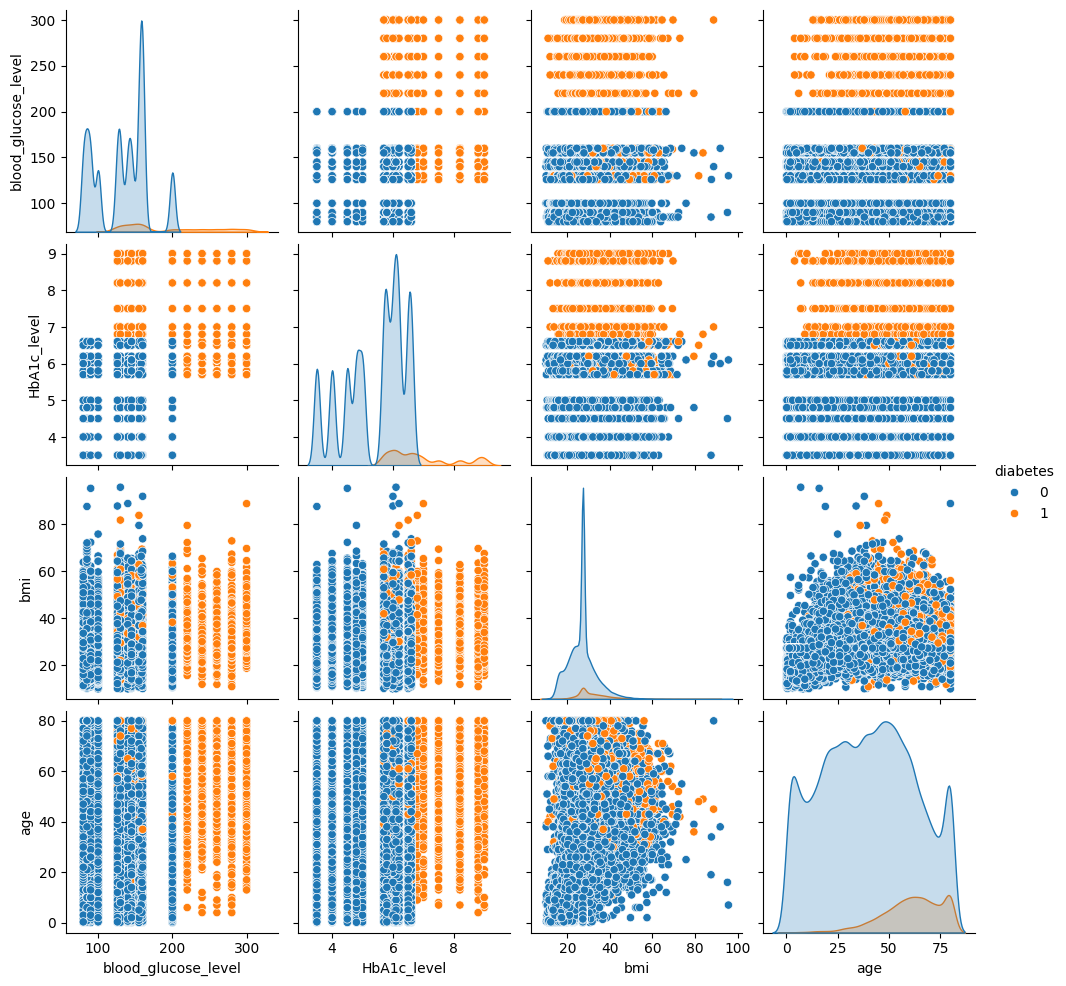

In [32]:
sns.pairplot(df[['blood_glucose_level', 'HbA1c_level', 'bmi', 'age', 'diabetes']],hue='diabetes')
plt.show()

A pair plot of key numerical variables shows clear separation between diabetic and non-diabetic patients, particularly for blood glucose and HbA1c levels.

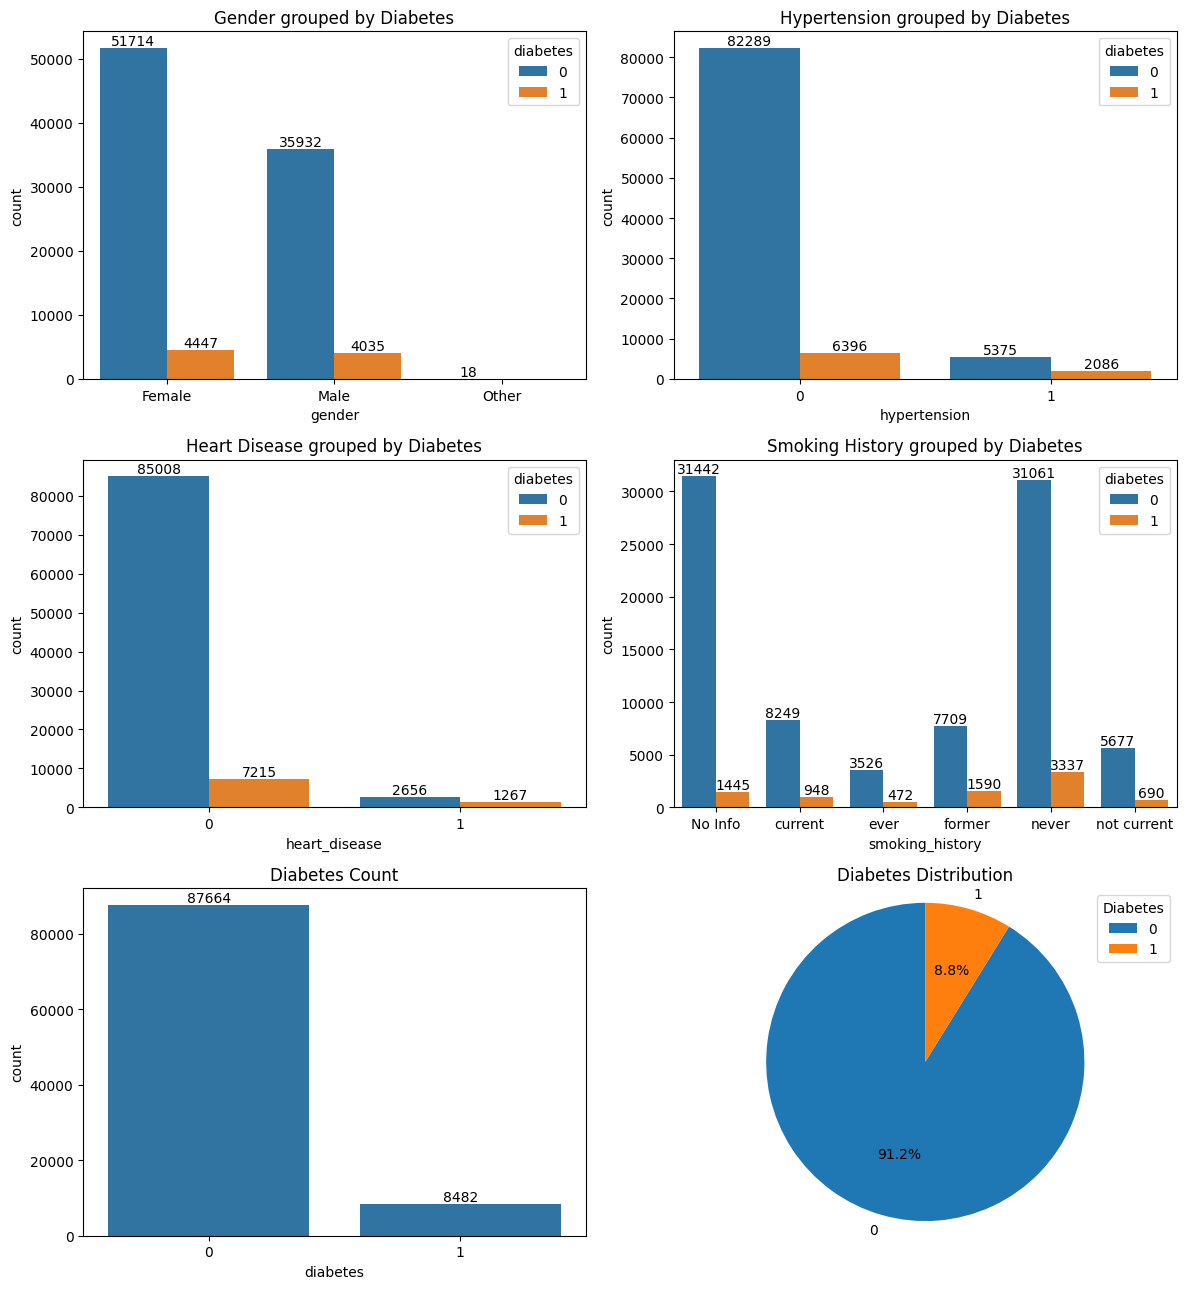

In [33]:
# Mixed Function to add counts on bars using the columns
def add_counts(ax):
    for container in ax.containers:
        ax.bar_label(container)

# Create subplot layout
fig, axes = plt.subplots(3, 2, figsize=(12, 13))

# Gender grouped by diabetes
ax = sns.countplot(ax=axes[0, 0], x='gender', hue='diabetes', data=df)
axes[0, 0].set_title('Gender grouped by Diabetes')
add_counts(ax)

# Hypertension grouped by diabetes
ax = sns.countplot(ax=axes[0, 1], x='hypertension', hue='diabetes', data=df)
axes[0, 1].set_title('Hypertension grouped by Diabetes')
add_counts(ax)

# Heart disease grouped by diabetes
ax = sns.countplot(ax=axes[1, 0], x='heart_disease', hue='diabetes', data=df)
axes[1, 0].set_title('Heart Disease grouped by Diabetes')
add_counts(ax)

# Smoking history grouped by diabetes
ax = sns.countplot(ax=axes[1, 1], x='smoking_history', hue='diabetes', data=df)
axes[1, 1].set_title('Smoking History grouped by Diabetes')
add_counts(ax)

# Diabetes count
ax = sns.countplot(ax=axes[2, 0], x='diabetes', data=df)
axes[2, 0].set_title('Diabetes Count')
add_counts(ax)

# Pie chart for diabetes
diabetes_counts = df['diabetes'].value_counts()
axes[2, 1].pie(diabetes_counts, labels=diabetes_counts.index,
               autopct='%1.1f%%', startangle=90)
axes[2, 1].set_title('Diabetes Distribution')
axes[2, 1].axis('equal')
axes[2, 1].legend(title='Diabetes')

plt.tight_layout()
plt.show()

### Multivariate analysis

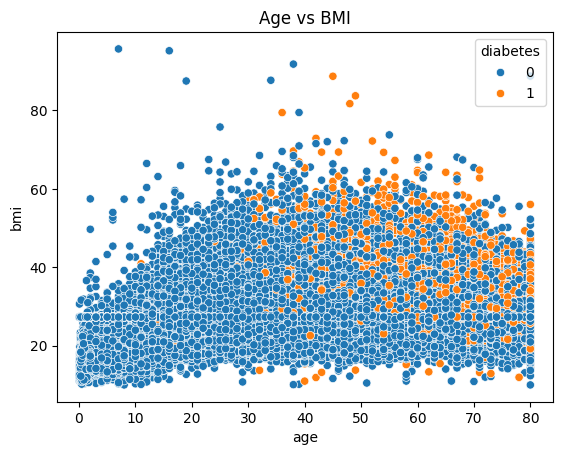

In [34]:
# Scatterplot Age vs BMI colored by Diabetes classification
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df)
plt.title('Age vs BMI')
plt.show()

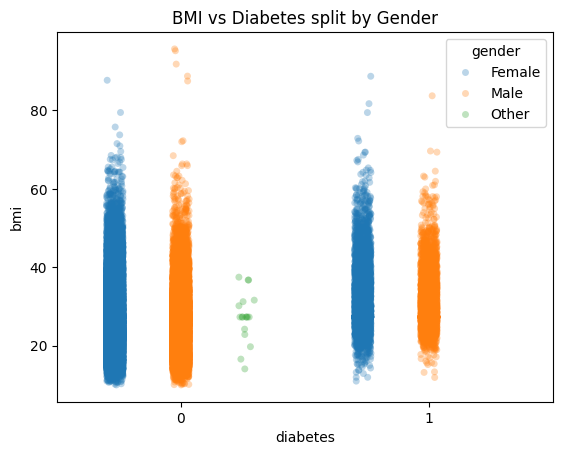

In [35]:
# Strip plot of BMI against diabetes split by gender
sns.stripplot(x='diabetes', y='bmi', hue='gender',data=df, dodge=True, alpha=0.3)
plt.title('BMI vs Diabetes split by Gender')
plt.show()

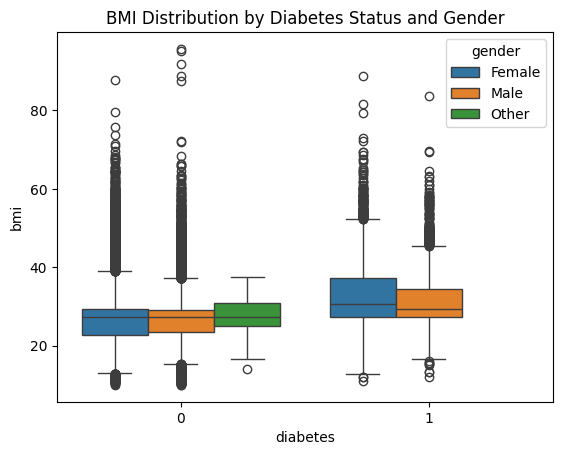

In [36]:
# Interaction between gender, BMI and diabetes
sns.boxplot(x='diabetes', y='bmi', hue='gender', data=df)
plt.title('BMI Distribution by Diabetes Status and Gender')
plt.show()

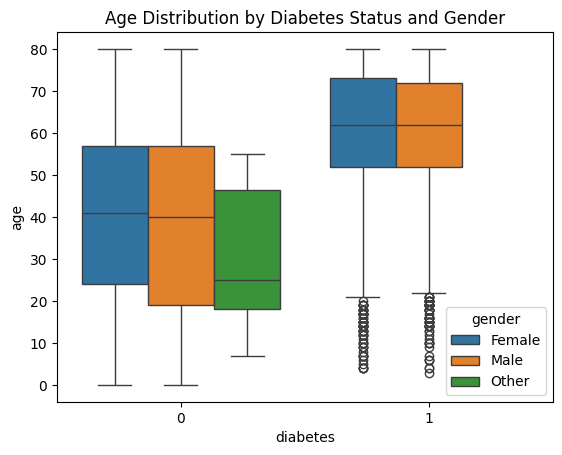

In [37]:
# Interaction between gender, Age and diabetes
sns.boxplot(x='diabetes', y='age', hue='gender', data=df)
plt.title('Age Distribution by Diabetes Status and Gender')
plt.show()

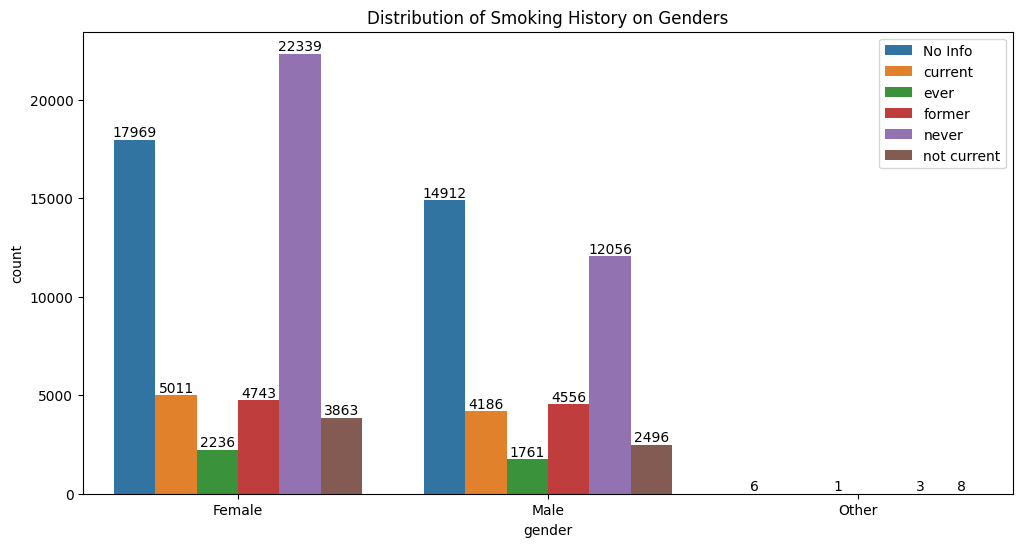

In [38]:
# the smoking history on genders. 
plt.figure(figsize=(12, 6))
sns.countplot(x="gender", data=df, hue="smoking_history")
for container in plt.gca().containers:
    plt.bar_label(container)
plt.legend(loc="upper right")
plt.title("Distribution of Smoking History on Genders")
plt.show()

The No Info... we can see how it affects the data clealry after checking the plot

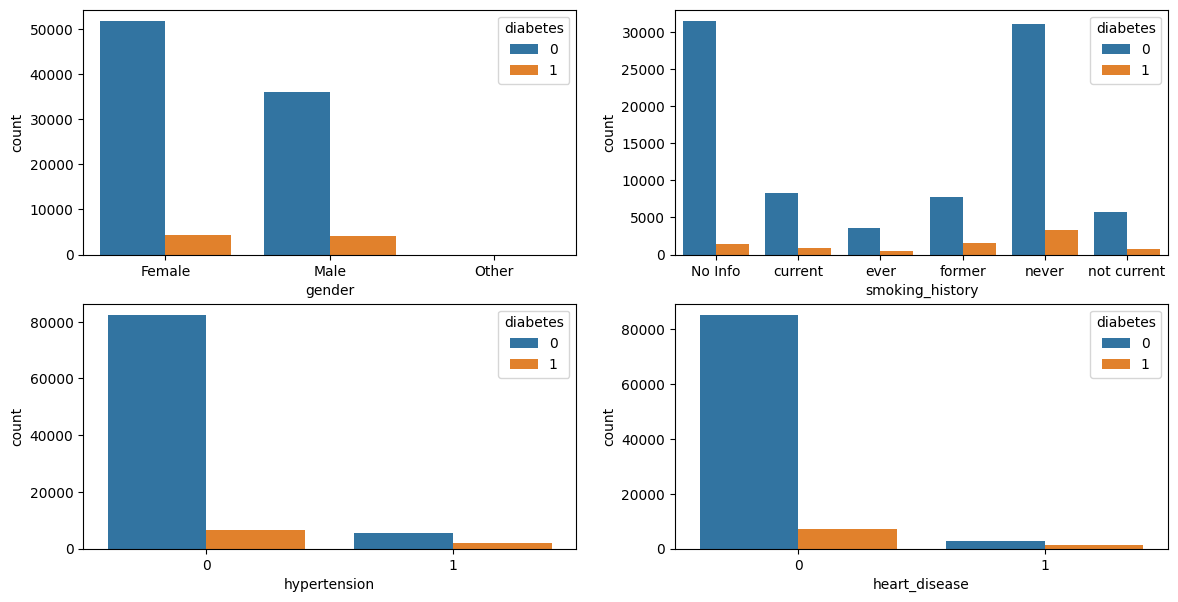

In [39]:
fig, axes = plt.subplots(nrows = 2, ncols = 2, figsize = (14,7))

sns.countplot(ax = axes[0,0], data = df, x = "gender", hue = "diabetes")
sns.countplot(ax = axes[0,1], data = df, x = "smoking_history", hue = "diabetes")
sns.countplot(ax = axes[1,0], data = df, x = "hypertension", hue = "diabetes")
sns.countplot(ax = axes[1,1], data = df, x = "heart_disease", hue = "diabetes")
plt.show()

Although there are more female patients in the dataset, the number of diabetes cases among males and females is very similar. This suggests that male patients may have a slightly higher tendency to develop diabetes compared to females.

Smoking history does not show a strong pattern in relation to diabetes. The distribution looks fairly balanced across categories, so it may not be a strong predictor in this dataset.

Hypertension also does not show a clear impact on diabetes based on the visual analysis. The difference between patients with and without hypertension is not very pronounced.

Most patients in the dataset do not have heart disease, and only a small portion do. From the plot, heart disease does not appear to show a strong relationship with diabetes in this dataset.

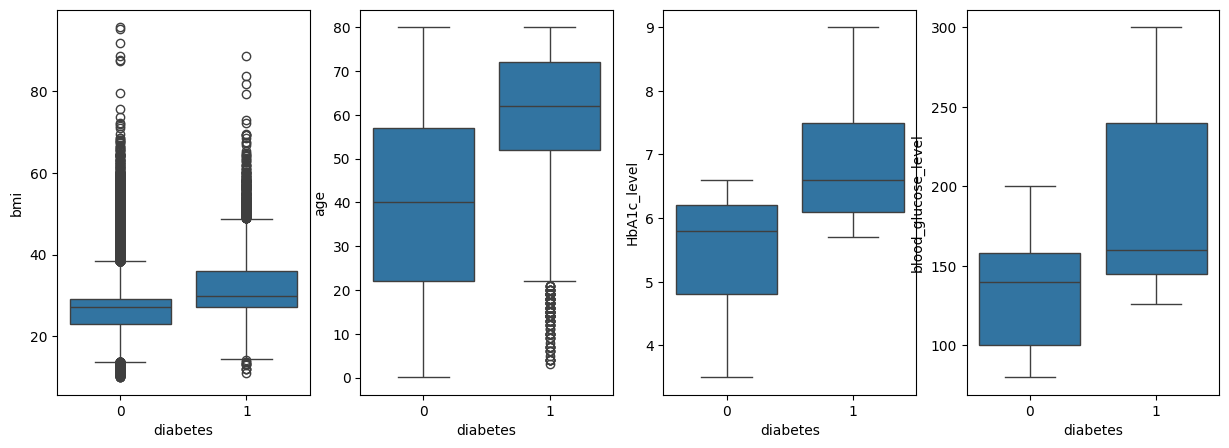

In [40]:
fig, axes = plt.subplots(nrows = 1, ncols = 4, figsize = (15,5))
sns.boxplot(ax = axes[0],x = "diabetes", y = "bmi", data = df)
sns.boxplot(ax = axes[1],x = "diabetes", y = "age", data = df)
sns.boxplot(ax = axes[2],x = "diabetes", y = "HbA1c_level", data = df)
sns.boxplot(ax = axes[3],x = "diabetes", y = "blood_glucose_level",data = df)
plt.show()

We can now observe how diabetes separates across numerical features.

Patients with higher BMI are more likely to have diabetes. However, there is still overlap between diabetic and non diabetic patients, so BMI alone cannot perfectly distinguish them.

Age shows a similar pattern. Older patients tend to have diabetes more often than younger patients. Still, there are overlaps and some outliers, meaning age by itself is not enough for clear classification.

HbA1c level appears to be a strong feature. The separation between diabetic and non diabetic patients is much clearer, with very little overlap and no extreme outliers. This makes it a strong candidate for classification.

Blood glucose level shows a pattern similar to HbA1c. The separation is clear and the overlap is small. This suggests that blood glucose level is also an important feature for predicting diabetes.

## Correlation

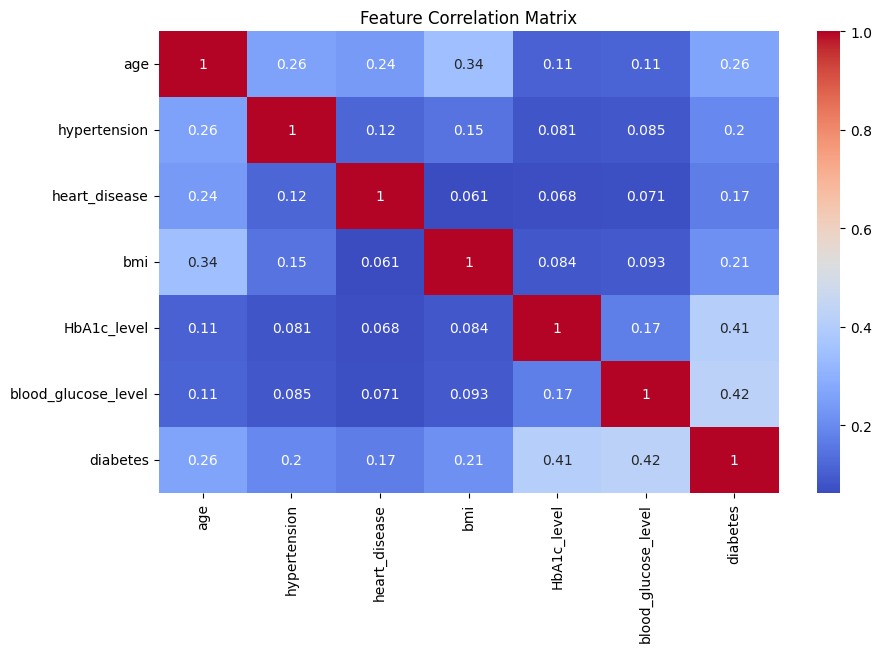

In [41]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

*The strong correlation between HbA1c and blood glucose suggests overlapping information. However, both are retained due to their clinical importance in diagnosing diabetes.*

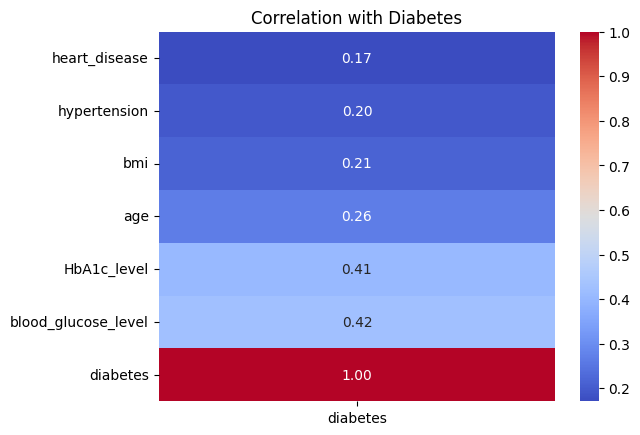

In [42]:
corr = df.corr(numeric_only=True)['diabetes'].sort_values()
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation with Diabetes')
plt.show()

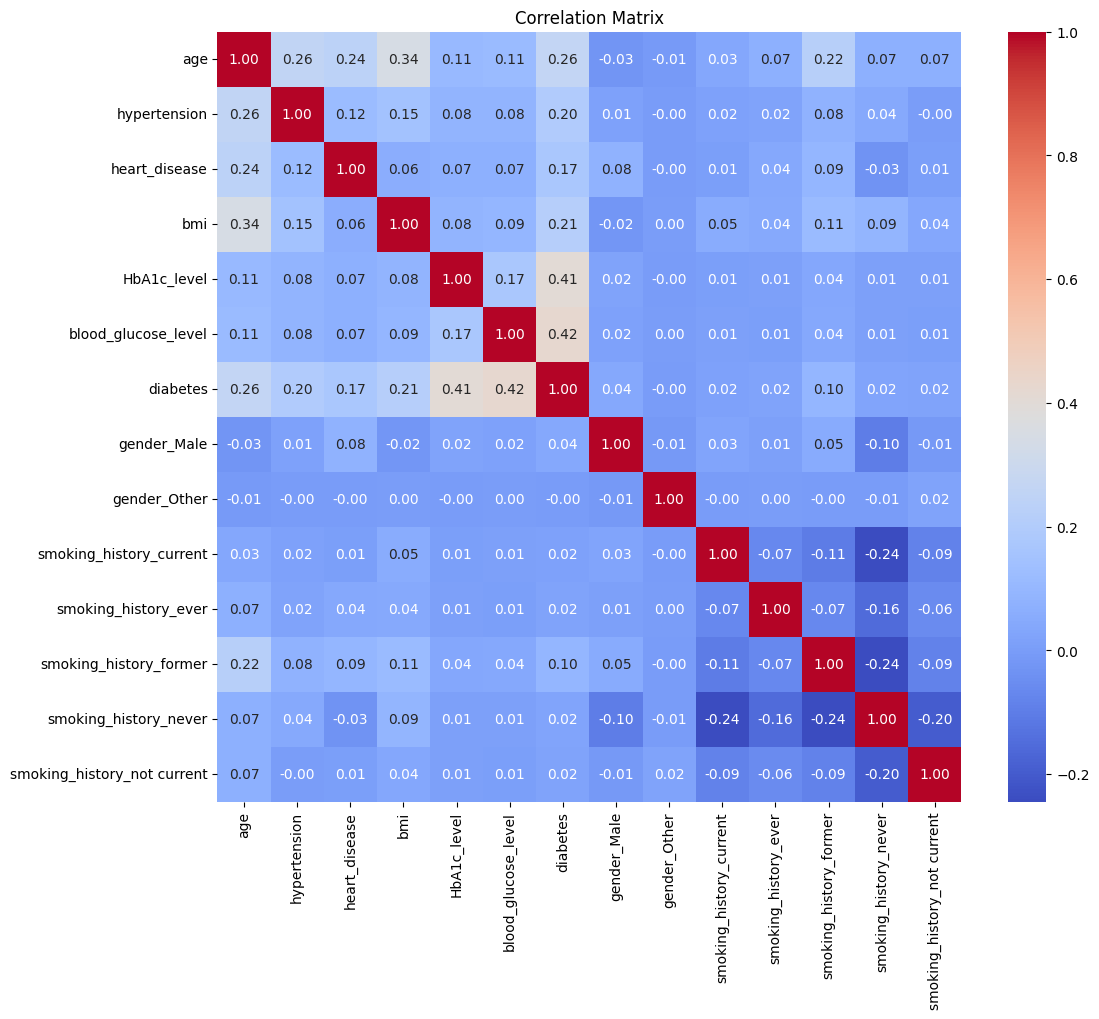

In [43]:
# Convert all categorical columns to numeric
df_encoded = pd.get_dummies(df, drop_first=True)

# Correlation matrix
corr = df_encoded.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

*Note: The ‘No Info’ category in smoking_history represents missing data. For hypothesis testing, these rows were excluded to ensure meaningful statistical results. This filtering was applied only to a subset of the data and not to the full dataset.*

### **Hypothesis Testing**

Statistical hypothesis tests were conducted to evaluate the relationship between selected variables and diabetes outcome. A significance level of α = 0.05 was used.


**Null Hypothesis (H₀):** No significant association exists between the variable and diabetes

**Alternative Hypothesis (H₁):** A significant association exists between the variable and diabetes

In [44]:
from scipy import stats
import pandas as pd

ALPHA = 0.05

### Test 1: Blood Glucose Level vs Diabetes (Independent Samples t-test)

H₀ / H₁ statement

**H₀:** No difference in mean blood glucose between diabetic and non-diabetic patients

**H₁:** A difference exists

**Test used:** Independent samples t-test

In [45]:
diabetic_bg     = df[df['diabetes'] == 1]['blood_glucose_level']
non_diabetic_bg = df[df['diabetes'] == 0]['blood_glucose_level']

t_stat, p_val = stats.ttest_ind(diabetic_bg, non_diabetic_bg)

print("Test 1: Blood Glucose vs Diabetes")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("Decision:", "Reject H0" if p_val < ALPHA else "Fail to reject H0")

Test 1: Blood Glucose vs Diabetes
t-statistic: 145.3048147699147
p-value: 0.0
Decision: Reject H0


**Conclusion (Test 1):** t = 145.30, p < 0.0001. We reject H₀.

There is a statistically significant difference in blood glucose levels between diabetic and non-diabetic patients.

Blood glucose is a strong predictor of diabetes.

### Test 2: HbA1c vs Diabetes (t-test)

**H₀:** No difference in mean HbA1c between diabetic and non-diabetic patients

**H₁:** A difference exists

**Test used:** Independent samples t-test

In [46]:
diabetic_hba     = df[df['diabetes'] == 1]['HbA1c_level']
non_diabetic_hba = df[df['diabetes'] == 0]['HbA1c_level']

t_stat, p_val = stats.ttest_ind(diabetic_hba, non_diabetic_hba)

print("\nTest 2: HbA1c vs Diabetes")
print("t-statistic:", t_stat)
print("p-value:", p_val)
print("Decision:", "Reject H0" if p_val < ALPHA else "Fail to reject H0")


Test 2: HbA1c vs Diabetes
t-statistic: 137.91901253274253
p-value: 0.0
Decision: Reject H0


**Conclusion (Test 2):**  t = 138.28, p < 0.0001. We reject H₀.

There is a statistically significant difference in HbA1c levels between diabetic (mean = 6.93%) and non-diabetic (mean = 5.40%) patients.

HbA1c is a key clinical marker for diabetes.


### Test 3: Hypertension vs Diabetes (Chi-square)


**H₀:** No association between hypertension and diabetes

**H₁:** An association exists

**Test used:** Chi-square test of independence

In [47]:
ct = pd.crosstab(df['hypertension'], df['diabetes'])

chi2, p_val, dof, expected = stats.chi2_contingency(ct)

print("\nTest 3: Hypertension vs Diabetes")
print("Chi-square:", chi2)
print("p-value:", p_val)
print("Decision:", "Reject H0" if p_val < ALPHA else "Fail to reject H0")


Test 3: Hypertension vs Diabetes
Chi-square: 3680.0329357951405
p-value: 0.0
Decision: Reject H0


**Conclusion (Test 3):**  χ² = 3910.71, p < 0.0001. We reject H₀.

There is a statistically significant association between hypertension and diabetes.

Patients with hypertension have a higher likelihood of being diabetic.

### Test 4: Heart Disease vs Diabetes (Chi-square)

**H₀:** No association between heart disease and diabetes

**H₁:** An association exists

**Test used:** Chi-square test of independence

In [48]:
ct = pd.crosstab(df['heart_disease'], df['diabetes'])

chi2, p_val, dof, expected = stats.chi2_contingency(ct)

print("\nTest 4: Heart Disease vs Diabetes")
print("Chi-square:", chi2)
print("p-value:", p_val)
print("Decision:", "Reject H0" if p_val < ALPHA else "Fail to reject H0")


Test 4: Heart Disease vs Diabetes
Chi-square: 2798.8652727125022
p-value: 0.0
Decision: Reject H0


**Conclusion (Test 4):**  χ² = 2945.85, p < 0.0001. We reject H₀.

There is a statistically significant association between heart disease and diabetes.

This suggests shared risk factors between the two conditions.

### Test 5: Smoking History vs Diabetes (Chi-square)


**H₀:** No association between smoking history and diabetes

**H₁:** An association exists

**Test used:** Chi-square test of independence

In [49]:
df_smoke = df[df['smoking_history'] != 'No Info']

ct = pd.crosstab(df_smoke['smoking_history'], df_smoke['diabetes'])

chi2, p_val, dof, expected = stats.chi2_contingency(ct)

print("\nTest 5: Smoking History vs Diabetes")
print("Chi-square:", chi2)
print("p-value:", p_val)
print("Decision:", "Reject H0" if p_val < ALPHA else "Fail to reject H0")


Test 5: Smoking History vs Diabetes
Chi-square: 414.7892081773776
p-value: 1.7723697842036993e-88
Decision: Reject H0


**Conclusion (Test 5):**  χ² = 430.91, p < 0.0001. We reject H₀.

There is a statistically significant association between smoking history and diabetes.

Former and current smokers show higher diabetes rates compared to non-smokers.

### Test 6: HbA1c vs Blood Glucose (Correlation)

**H₀:** No linear relationship between HbA1c and blood glucose

**H₁:** A linear relationship exists

**Test used:** Pearson correlation coefficient

In [50]:
r, p_val = stats.pearsonr(df['HbA1c_level'], df['blood_glucose_level'])

print("\nTest 6: HbA1c vs Blood Glucose")
print("Correlation (r):", r)
print("p-value:", p_val)
print("Decision:", "Reject H0" if p_val < ALPHA else "Fail to reject H0")


Test 6: HbA1c vs Blood Glucose
Correlation (r): 0.17161527610856478
p-value: 0.0
Decision: Reject H0


**Conclusion (Test 6):**  r = 0.1667, p < 0.0001. We reject H₀.

There is a statistically significant but weak positive correlation between HbA1c and blood glucose levels.

Both variables are important predictors of diabetes.

### **Hypothesis Testing Summary**


| Test | Variable                    | Test Type                       | p-value  | Decision  |
| ---- | --------------------------- | ------------------------------- | -------- | --------- |
| 1    | Blood glucose vs diabetes   | t-test                          | < 0.0001 | Reject H₀ |
| 2    | HbA1c level vs diabetes     | t-test                          | < 0.0001 | Reject H₀ |
| 3    | Hypertension vs diabetes    | Chi-square                      | < 0.0001 | Reject H₀ |
| 4    | Heart disease vs diabetes   | Chi-square                      | < 0.0001 | Reject H₀ |
| 5    | Smoking history vs diabetes | Chi-square                      | < 0.0001 | Reject H₀ |
| 6    | HbA1c vs blood glucose      | Pearson correlation coefficient | < 0.0001 | Reject H₀ |



**Overall conclusion:** All tests show statistically significant results at α = 0.05.

Blood glucose and HbA1c demonstrate the strongest effects and are key indicators of diabetes.

Hypertension, heart disease, and smoking history are also significantly associated with diabetes, highlighting the role of comorbidities and lifestyle factors.

**Based on exploratory analysis and hypothesis testing, HbA1c level and blood glucose level emerge as the strongest predictors, while other variables provide supporting context.**

### **Feature Engineering**

*Note: The ‘No Info’ category was retained in the main dataset during preprocessing and label encoding. As a result, it is treated as a separate category in the model, even though it represents missing information. A more robust approach would be to treat ‘No Info’ as missing data and handle it before encoding.*

Categorical variables were encoded using label encoding for simplicity, although one hot encoding could improve model interpretability.

In [51]:
# LabelEncoder

from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
df["gender"] = le_gender.fit_transform(df["gender"])

le_smoking = LabelEncoder()
df["smoking_history"] = le_smoking.fit_transform(df["smoking_history"])

In [52]:
df["gender"].value_counts()

gender
0    56161
1    39967
2       18
Name: count, dtype: int64

In [53]:
df["smoking_history"].value_counts()

smoking_history
4    34398
0    32887
3     9299
1     9197
5     6367
2     3998
Name: count, dtype: int64

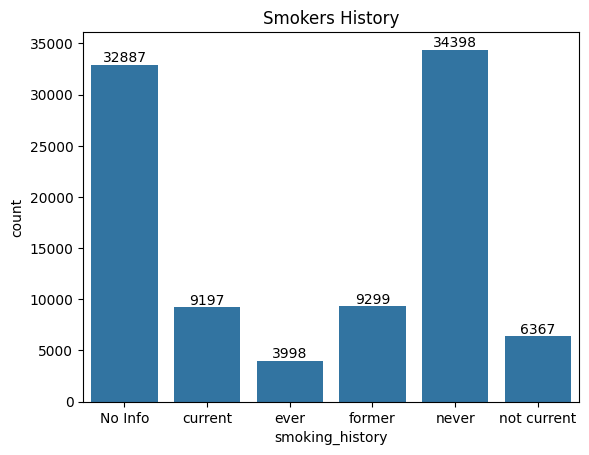


Smoking History:

    No Info 32887 labeled as 0
    never 34398 labeled as 4
    former 9299 labeled as 3
    current 9197 labeled as 1
    not current 6367 labeled as 5
    ever 3998 labeled as 2

### **LogisticRegression**

Accuracy: 0.9569942797711909
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



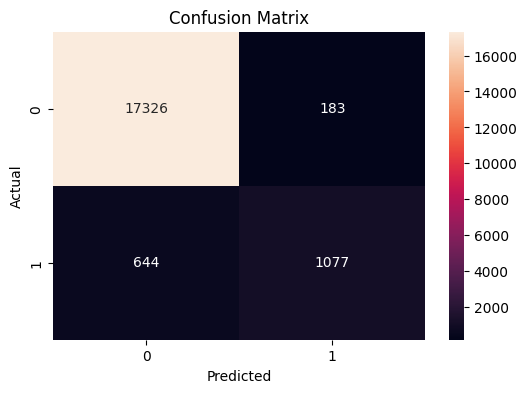

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create model
model = LogisticRegression(max_iter=1000)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# classification report
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

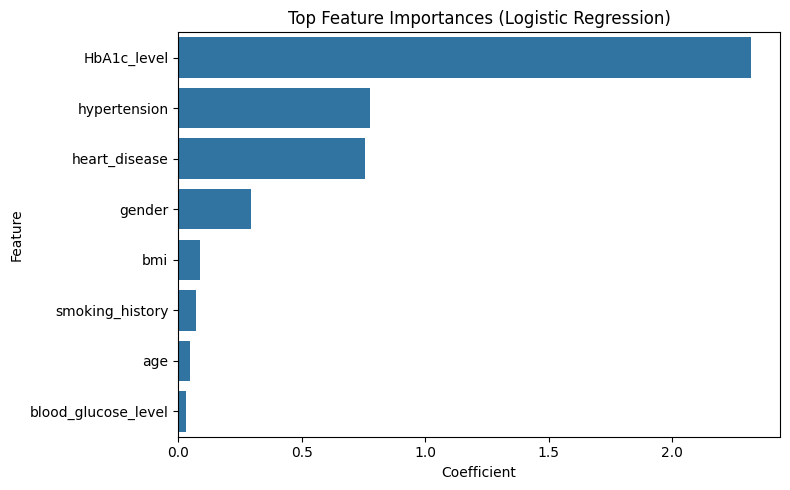

In [55]:
# Feature Importance from your Logistic Regression model

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

# Sort by absolute value
coef_df = coef_df.reindex(
    coef_df['Coefficient'].abs().sort_values(ascending=False).index
).head(15)

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=coef_df, x='Coefficient', y='Feature')
plt.title('Top Feature Importances (Logistic Regression)')
plt.tight_layout()
plt.show()

### **DecisionTreeClassifier**

Accuracy: 0.9473738949557983
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     17509
           1       0.70      0.73      0.71      1721

    accuracy                           0.95     19230
   macro avg       0.83      0.85      0.84     19230
weighted avg       0.95      0.95      0.95     19230



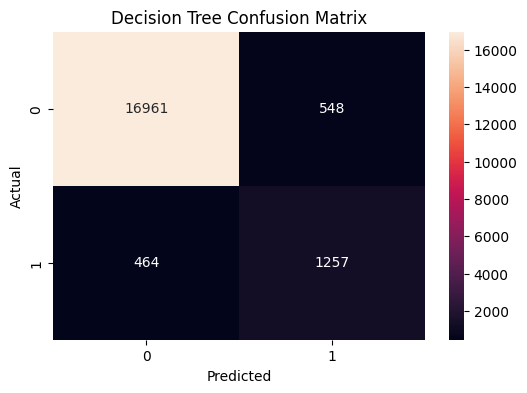

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define features and target
X = df.drop("diabetes", axis=1)
y = df["diabetes"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# classification report
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### **Random Forest Classifier**

Random Forest Accuracy: 0.9686427457098284
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.94      0.69      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



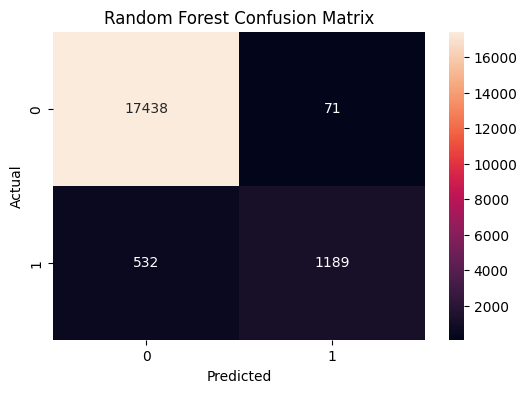

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the model
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

# Print classification report
print(classification_report(y_test, y_pred_rf))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

               Feature  Importance
6          HbA1c_level    0.385178
7  blood_glucose_level    0.326172
5                  bmi    0.122091
1                  age    0.105620
4      smoking_history    0.028522
2         hypertension    0.015442
3        heart_disease    0.010089
0               gender    0.006887


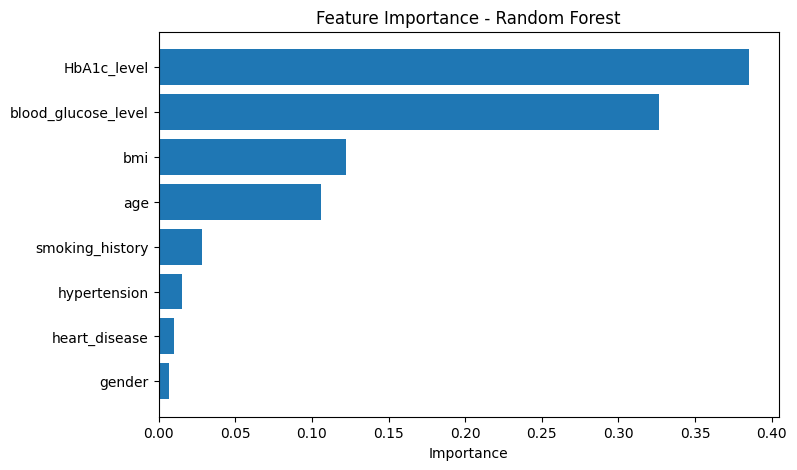

In [58]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importances = rf_model.feature_importances_

# Create dataframe
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print
print(feature_importance_df)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.show()

### **Building Model XGBoost For Diabetes**

XGBoost Accuracy: 0.9699427977119085
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       0.96      0.70      0.81      1721

    accuracy                           0.97     19230
   macro avg       0.96      0.85      0.89     19230
weighted avg       0.97      0.97      0.97     19230



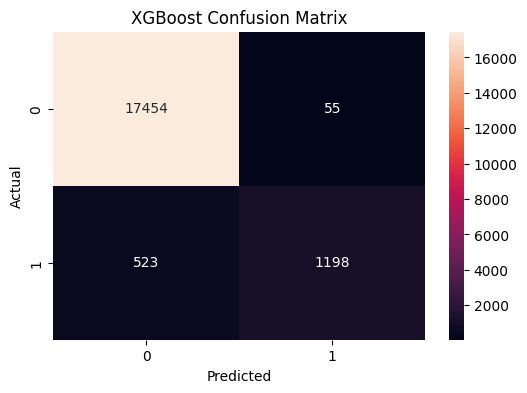

In [59]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create Model
xgb_model = XGBClassifier(random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate accuracy
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

# Print classification report
print(classification_report(y_test, y_pred_xgb))

# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

*Tree based models such as Random Forest and XGBoost perform better than Logistic Regression. This indicates that the dataset contains non linear patterns that are better captured by these models.*

In [60]:
# Save the model

import pickle

with open("diabetes_xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

### **Predicting Custom Data**

In [61]:
#Using the same feature order as the dataset

features = X.columns

custom_data = [
[1,45,0,0,2,25.6,6.5,110],
[0,35,1,0,1,28.2,7.2,130],
[1,55,1,1,3,31.4,8.0,150],
[0,42,0,1,0,26.9,7.0,120],
[1,50,1,0,2,29.7,7.8,140]]

custom_df = pd.DataFrame(custom_data, columns=features)

predictions = xgb_model.predict(custom_df)

for i, pred in enumerate(predictions):
    if pred == 0:
        print("Person", i+1, "is not predicted to have diabetes")
    else:
        print("Person", i+1, "is predicted to have diabetes")

Person 1 is not predicted to have diabetes
Person 2 is predicted to have diabetes
Person 3 is predicted to have diabetes
Person 4 is predicted to have diabetes
Person 5 is predicted to have diabetes


### **Building XGBoost model for hypertension**

XGBoost Accuracy: 0.9190327613104524
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     17697
           1       0.33      0.02      0.03      1533

    accuracy                           0.92     19230
   macro avg       0.62      0.51      0.49     19230
weighted avg       0.87      0.92      0.88     19230



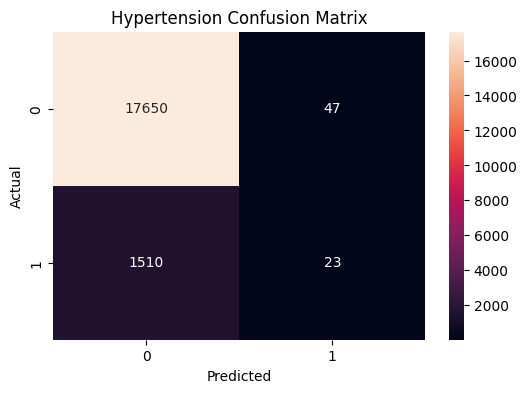

In [62]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Define features and target
X = df.drop("hypertension", axis=1)
y = df["hypertension"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42)

# Create the model
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42)

# train the model
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred = xgb_model.predict(X_test)

# Evaluate the model
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Hypertension Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [63]:
# Save the model

import pickle

with open("hypertension_xgboost_model.pkl", "wb") as f:
    pickle.dump(xgb_model, f)

### **Predict whether a patient has diabetes or not from the data**

In [64]:
print(X_train.columns)

Index(['gender', 'age', 'heart_disease', 'smoking_history', 'bmi',
       'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')


In [65]:
print(rf_model.feature_names_in_)

['gender' 'age' 'hypertension' 'heart_disease' 'smoking_history' 'bmi'
 'HbA1c_level' 'blood_glucose_level']


In [66]:
#gender=0
#age=28
#hypertension=0
#heart_disease=0
#smoking_history=0
#bmi=22.3
#HbA1c_level=5.2
#blood_glucose_level=95


custom_data = [
[0,28,0,0,0,22.3,5.2,95],
[1,40,1,0,1,27.5,6.1,115],
[1,55,1,1,2,33.8,7.8,165],
[0,65,1,1,3,36.5,9.2,210],
[1,72,1,1,3,38.9,10.1,240]]

custom_df = pd.DataFrame(custom_data, columns=rf_model.feature_names_in_)

predictions = rf_model.predict(custom_df)

for i, pred in enumerate(predictions):
    if pred == 0:
        print("Patient", i+1, "is predicted NOT to have diabetes")
    else:
        print("Patient", i+1, "is predicted to have diabetes")

Patient 1 is predicted NOT to have diabetes
Patient 2 is predicted NOT to have diabetes
Patient 3 is predicted to have diabetes
Patient 4 is predicted to have diabetes
Patient 5 is predicted to have diabetes


**Limitations**

*The dataset includes a ‘No Info’ category which represents missing data but was treated as a valid category during modeling. This may introduce bias. Additionally, class imbalance may affect the model’s ability to accurately predict diabetic cases.*

### *Results*

Five sample patient profiles were created using clinical indicators such as age, BMI, HbA1c level, blood glucose level, smoking history, hypertension, and heart disease. The trained Random Forest model was used to predict diabetes risk for each patient.

    Patient 1
Predicted not to have diabetes. This patient has low BMI, low HbA1c, and normal glucose levels.

    Patient 2
Predicted not to have diabetes. The health indicators suggest moderate risk but remain within non diabetic ranges.

    Patient 3
Predicted to have diabetes. Higher BMI, HbA1c, and blood glucose levels increase the predicted risk.

    Patient 4
Predicted to have diabetes. Older age combined with heart disease, high BMI, and elevated glucose contributes to higher risk.

    Patient 5
Predicted to have diabetes. Very high HbA1c, blood glucose, and BMI indicate strong likelihood of diabetes.


    Conclusion:
    The results show that clinical indicators such as HbA1c level and blood glucose level are the most influential predictors of diabetes. While demographic and lifestyle factors contribute to prediction, their impact is smaller. This demonstrates how machine learning can support early detection of diabetes using routine health data.

### **Model Deployment**

In [67]:
import pandas as pd
import pickle
import gradio as gr

# Load model
with open("diabetes_xgboost_model.pkl", "rb") as f:
    model = pickle.load(f)

# Correct feature order
columns = [
    'gender', 'age', 'hypertension', 'heart_disease',
    'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level'
]

# Store history
history = []

def predict_diabetes(gender, age, hypertension, heart_disease,
                    smoking_history, bmi, HbA1c_level, blood_glucose_level):

    global history

    try:
        # Convert inputs
        gender = int(gender)
        age = float(age)
        hypertension = int(hypertension)
        heart_disease = int(heart_disease)
        smoking_history = int(smoking_history)
        bmi = float(bmi)
        HbA1c_level = float(HbA1c_level)
        blood_glucose_level = float(blood_glucose_level)

        # Create dataframe
        raw = pd.DataFrame([[
            gender, age, hypertension, heart_disease,
            smoking_history, bmi, HbA1c_level, blood_glucose_level
        ]], columns=columns)

        # Predict
        prediction = model.predict(raw)[0]
        probability = model.predict_proba(raw)[0][1]

        label = "Diabetic" if prediction == 1 else "Not Diabetic"

        # Risk level
        if probability < 0.3:
            risk = "Low Risk"
        elif probability < 0.7:
            risk = "Moderate Risk"
        else:
            risk = "High Risk"

        result = f"{label} | {risk} | Probability: {probability*100:.4f}%"

        # Save to history
        history.append([
            gender, age, hypertension, heart_disease,
            smoking_history, bmi, HbA1c_level, blood_glucose_level,
            label, risk, f"{probability*100:.2f}%"
        ])

        # Convert to table
        df_history = pd.DataFrame(history, columns=[
            "Gender", "Age", "Hypertension", "Heart Disease",
            "Smoking", "BMI", "HbA1c", "Glucose",
            "Prediction", "Risk", "Probability"
        ])

        return result, df_history

    except Exception as e:
        return f"Error: {str(e)}", pd.DataFrame()


In [68]:

interface = gr.Interface(
    fn=predict_diabetes,
    inputs=[
        gr.Radio([0, 1], value=0, label="Gender (0 = Female, 1 = Male)"),
        gr.Number(value=30, label="Age"),
        gr.Radio([0, 1], value=0, label="Hypertension (0 = No, 1 = Yes)"),
        gr.Radio([0, 1], value=0, label="Heart Disease (0 = No, 1 = Yes)"),
        gr.Number(value=0, label="Smoking History (0–5)"),
        gr.Number(value=25.0, label="BMI"),
        gr.Number(value=5.5, label="HbA1c Level"),
        gr.Number(value=100, label="Blood Glucose Level")
    ],
    outputs=[
        gr.Text(label="Prediction"),
        gr.Dataframe(label="Prediction History")
    ],
    title="Diabetes Prediction",
    description="Enter patient details to predict diabetes risk",

    # examples
    examples=[
        [0, 25, 0, 0, 0, 21.5, 5.1, 90],     # Low
        [1, 45, 1, 0, 2, 28.5, 6.2, 130],    # Moderate
        [1, 65, 1, 1, 3, 36.0, 9.0, 220]     # High
    ]
)

interface.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


**Below are Examples for checking the model**

Low Risk

inputs=[
    gr.Radio([0, 1], value=0, label="Gender (0 = Female, 1 = Male)"),
    gr.Number(value=25, label="Age"),
    gr.Radio([0, 1], value=0, label="Hypertension (0 = No, 1 = Yes)"),
    gr.Radio([0, 1], value=0, label="Heart Disease (0 = No, 1 = Yes)"),
    gr.Number(value=0, label="Smoking History (0–5)"),
    gr.Number(value=21.5, label="BMI"),
    gr.Number(value=5.1, label="HbA1c Level"),
    gr.Number(value=90, label="Blood Glucose Level")
]

Moderate Risk

inputs=[
    gr.Radio([0, 1], value=1, label="Gender (0 = Female, 1 = Male)"),
    gr.Number(value=45, label="Age"),
    gr.Radio([0, 1], value=1, label="Hypertension (0 = No, 1 = Yes)"),
    gr.Radio([0, 1], value=0, label="Heart Disease (0 = No, 1 = Yes)"),
    gr.Number(value=2, label="Smoking History (0–5)"),
    gr.Number(value=28.5, label="BMI"),
    gr.Number(value=6.2, label="HbA1c Level"),
    gr.Number(value=130, label="Blood Glucose Level")
]

High Risk

inputs=[
    gr.Radio([0, 1], value=1, label="Gender (0 = Female, 1 = Male)"),
    gr.Number(value=65, label="Age"),
    gr.Radio([0, 1], value=1, label="Hypertension (0 = No, 1 = Yes)"),
    gr.Radio([0, 1], value=1, label="Heart Disease (0 = No, 1 = Yes)"),
    gr.Number(value=3, label="Smoking History (0–5)"),
    gr.Number(value=36.0, label="BMI"),
    gr.Number(value=9.0, label="HbA1c Level"),
    gr.Number(value=220, label="Blood Glucose Level")
]